In [63]:
!pip install pandas numpy matplotlib seaborn kagglehub

   ---------------------------------------- 0.0/676.6 kB ? eta -:--:--
   ---------------------------------------- 676.6/676.6 kB 14.0 MB/s  0:00:00

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- --

In [64]:
import kagglehub
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [66]:
path = kagglehub.dataset_download("anlgrbz/student-demographics-online-education-dataoulad")
print("Path to dataset:", path)

Path to dataset: C:\Users\Admin\.cache\kagglehub\datasets\anlgrbz\student-demographics-online-education-dataoulad\versions\1


In [67]:
df_assessments = pd.read_csv(path + '\\assessments.csv') 

In [68]:
df_assessments.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [69]:
df_assessments.describe()

,id_assessment,date,weight
count,206.000000,195.000000,206.000000
mean,26473.975728,145.005128,20.873786
std,10098.625521,76.001119,30.384224
min,1752.000000,12.000000,0.000000
25%,15023.250000,71.000000,0.000000
50%,25364.500000,152.000000,12.500000
75%,34891.750000,222.000000,24.250000
max,40088.000000,261.000000,100.000000


In [70]:
df_courses = pd.read_csv(path + '\\courses.csv')
df_courses.head()

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


In [71]:
df_courses.describe()

,module_presentation_length
count,22.000000
mean,255.545455
std,13.654677
min,234.000000
25%,241.000000
50%,261.500000
75%,268.000000
max,269.000000


In [72]:
df_studentAssessments = pd.read_csv(path + '\\studentAssessment.csv')
df_studentAssessments.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [75]:
df_students = pd.read_csv(path + '\\studentInfo.csv')
df_students.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [74]:
df_studentRegistration = pd.read_csv(path + '\\studentRegistration.csv')
df_studentRegistration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [76]:
df_studentVle = pd.read_csv(path + '\\studentVle.csv')
df_studentVle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [77]:
df_vle = pd.read_csv(path + '\\vle.csv')
df_vle.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [55]:
# Define a helper to summarize each dataframe

def summarize_df(df, name):
    print(f"=== {name} ===")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print("dtypes:")
    print(df.dtypes)
    print("\nnull counts:")
    print(df.isna().sum().sort_values(ascending=False).head(30))
    print("duplicate rows:", df.duplicated().sum())
    print("\n")

for name, df in [
    ("assessments", df_assessments),
    ("courses", df_courses),
    ("studentAssessment", df_studentAssessments),
    ("studentInfo", df_students),
    ("studentRegistration", df_studentRegistration),
    ("studentVle", df_studentVle),
    ("vle", df_vle),
]:
    summarize_df(df, name)



=== assessments ===
shape: (206, 6)
columns: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
dtypes:
code_module              str
code_presentation        str
id_assessment          int64
assessment_type          str
date                 float64
weight               float64
dtype: object

null counts:
date                 11
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
weight                0
dtype: int64
duplicate rows: 0


=== courses ===
shape: (22, 3)
columns: ['code_module', 'code_presentation', 'module_presentation_length']
dtypes:
code_module                     str
code_presentation               str
module_presentation_length    int64
dtype: object

null counts:
code_module                   0
code_presentation             0
module_presentation_length    0
dtype: int64
duplicate rows: 0


=== studentAssessment ===
shape: (173912, 5)
columns: ['id_assessment', 'id_student', 'date_submi

# Assessments analysis
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0
assessment_type
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64
count    206.000000
mean      20.873786
std       30.384224
min        0.000000
25%        0.000000
50%       12.500000
75%       24.250000
max      100.000000
Name: weight, dtype: float64
missing dates: 11
code_module  code_presentation
DDD          2013B                14
FFF          2014B                13
             2013B                13
             2013J                13
             2014J                13
BBB     

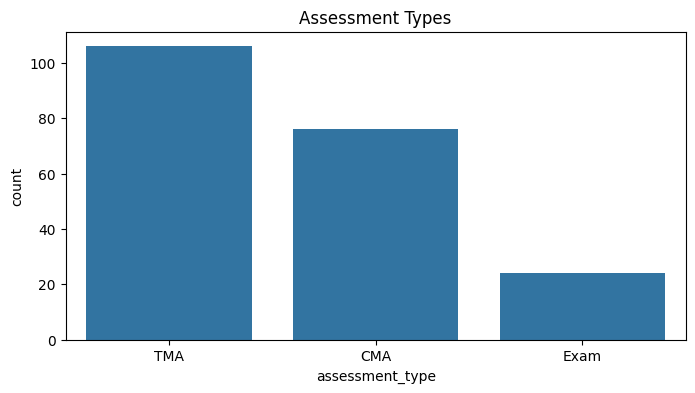

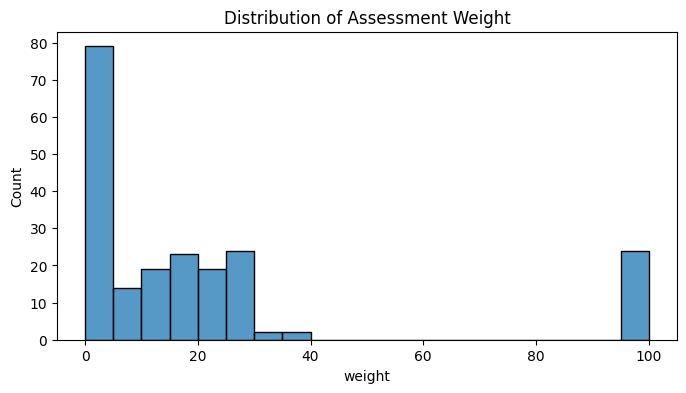

In [56]:
# Assessments analysis
print("# Assessments analysis")
print(df_assessments.head())
print(df_assessments['assessment_type'].value_counts())
print(df_assessments['weight'].describe())
print('missing dates:', df_assessments['date'].isna().sum())
print(df_assessments.groupby(['code_module', 'code_presentation'])['id_assessment'].nunique().sort_values(ascending=False).head(20))

plt.figure(figsize=(8, 4))
sns.countplot(data=df_assessments, x='assessment_type', order=df_assessments['assessment_type'].value_counts().index)
plt.title('Assessment Types')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_assessments['weight'].dropna().astype(float), bins=20, kde=False)
plt.title('Distribution of Assessment Weight')
plt.xlabel('weight')
plt.show()



# Courses analysis
  code_module code_presentation  module_presentation_length
0         AAA             2013J                         268
1         AAA             2014J                         269
2         BBB             2013J                         268
3         BBB             2014J                         262
4         BBB             2013B                         240
       code_module code_presentation  module_presentation_length
count           22                22                   22.000000
unique           7                 4                         NaN
top            BBB             2014J                         NaN
freq             4                 7                         NaN
mean           NaN               NaN                  255.545455
std            NaN               NaN                   13.654677
min            NaN               NaN                  234.000000
25%            NaN               NaN                  241.000000
50%            NaN               NaN

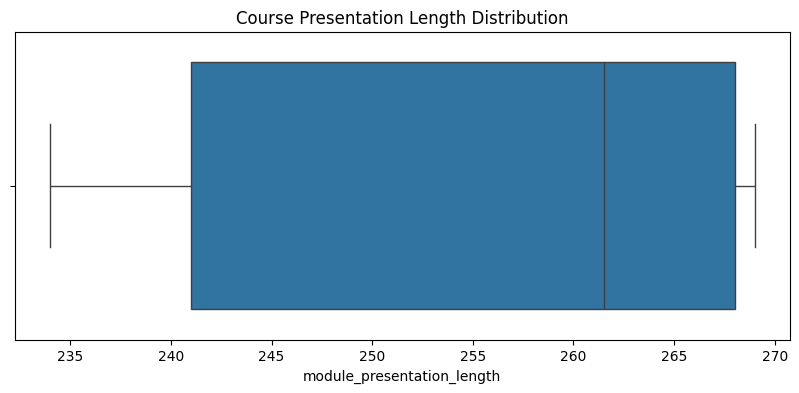

In [57]:
# Courses analysis
print("# Courses analysis")
print(df_courses.head())
print(df_courses.describe(include='all'))
print('unique module/presentation combos:', df_courses.groupby(['code_module', 'code_presentation']).size().shape[0])
print(df_courses.groupby('code_module')['module_presentation_length'].describe())

plt.figure(figsize=(10, 4))
sns.boxplot(data=df_courses, x='module_presentation_length')
plt.title('Course Presentation Length Distribution')
plt.show()


# Student info analysis
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60  

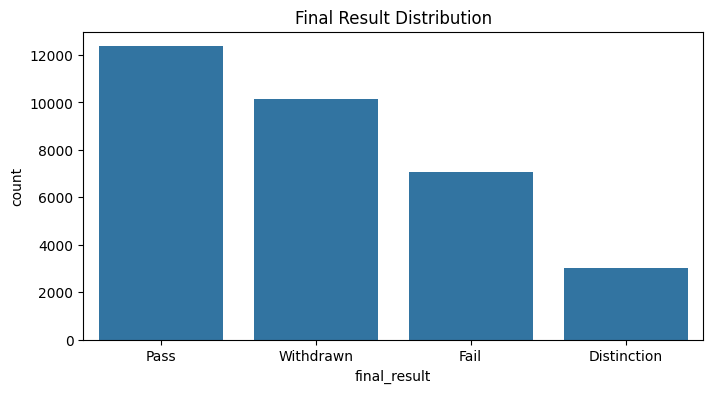

In [58]:
# Student info analysis
print("# Student info analysis")
print(df_students.head())
print('final result counts:')
print(df_students['final_result'].value_counts(dropna=False))
for col in ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability']:
    if col in df_students.columns:
        print(f'--- {col} ---')
        print(df_students[col].value_counts(dropna=False).head(20))

plt.figure(figsize=(8, 4))
sns.countplot(data=df_students, x='final_result', order=df_students['final_result'].value_counts().index)
plt.title('Final Result Distribution')
plt.show()


# Student assessment analysis
   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22          0   70.0
2           1752       31604              17          0   72.0
3           1752       32885              26          0   69.0
4           1752       38053              19          0   79.0
       id_assessment    id_student  date_submitted      is_banked  \
count  173912.000000  1.739120e+05   173912.000000  173912.000000   
mean    26553.803556  7.051507e+05      116.032942       0.010977   
std      8829.784254  5.523952e+05       71.484148       0.104194   
min      1752.000000  6.516000e+03      -11.000000       0.000000   
25%     15022.000000  5.044290e+05       51.000000       0.000000   
50%     25359.000000  5.852080e+05      116.000000       0.000000   
75%     34883.000000  6.344980e+05      173.000000       0.000000   
max     37443.000000  2.698588e+06      

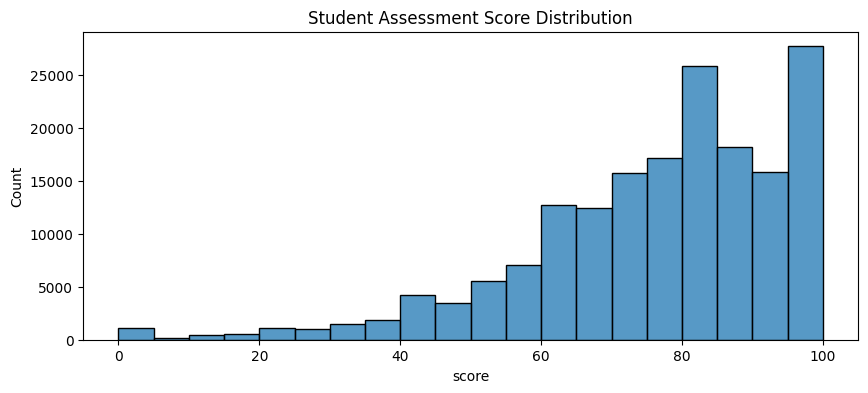

scores by assessment type:
                   count       mean        std  min   25%   50%   75%    max
assessment_type                                                             
CMA              70527.0  81.027053  17.836026  0.0  72.0  82.0  98.0  100.0
Exam              4959.0  65.572898  20.579186  0.0  51.0  67.0  82.0  100.0
TMA              98253.0  72.563392  18.432823  0.0  63.0  76.0  86.0  100.0


In [59]:
# Student assessment analysis
print("# Student assessment analysis")
print(df_studentAssessments.head())
print(df_studentAssessments.describe(include='all'))
print('missing scores:', df_studentAssessments['score'].isna().sum())
print('banked counts:')
print(df_studentAssessments['is_banked'].value_counts(dropna=False))

plt.figure(figsize=(10, 4))
sns.histplot(df_studentAssessments['score'].dropna().astype(float), bins=20)
plt.title('Student Assessment Score Distribution')
plt.xlabel('score')
plt.show()

merged_scores = df_studentAssessments.merge(df_assessments, on='id_assessment', how='left')
print('scores by assessment type:')
print(merged_scores.groupby('assessment_type')['score'].describe())



# Registration analysis
  code_module code_presentation  id_student  date_registration  \
0         AAA             2013J       11391             -159.0   
1         AAA             2013J       28400              -53.0   
2         AAA             2013J       30268              -92.0   
3         AAA             2013J       31604              -52.0   
4         AAA             2013J       32885             -176.0   

   date_unregistration  
0                  NaN  
1                  NaN  
2                 12.0  
3                  NaN  
4                  NaN  
       code_module code_presentation    id_student  date_registration  \
count        32593             32593  3.259300e+04       32548.000000   
unique           7                 4           NaN                NaN   
top            BBB             2014J           NaN                NaN   
freq          7909             11260           NaN                NaN   
mean           NaN               NaN  7.066877e+05         -69.4

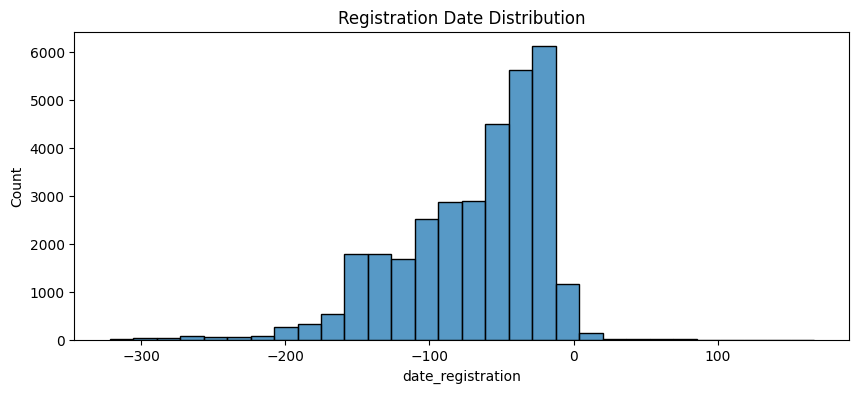

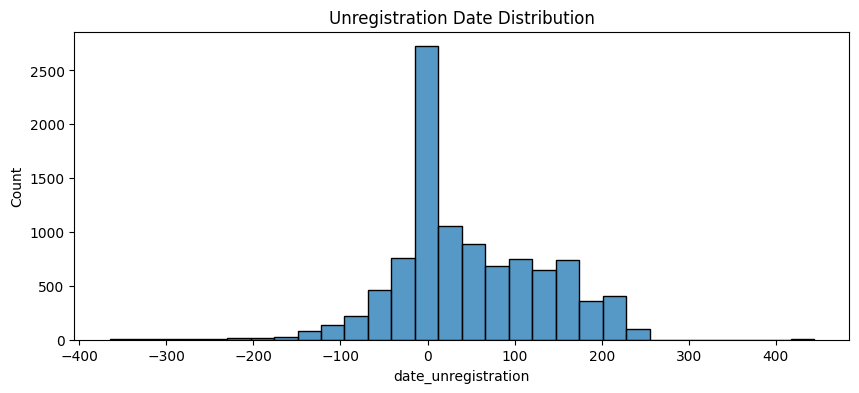

In [60]:
# Registration analysis
print("# Registration analysis")
print(df_studentRegistration.head())
print(df_studentRegistration.describe(include='all'))
print('missing unregistration dates:', df_studentRegistration['date_unregistration'].isna().sum())

plt.figure(figsize=(10, 4))
sns.histplot(df_studentRegistration['date_registration'].dropna().astype(float), bins=30)
plt.title('Registration Date Distribution')
plt.xlabel('date_registration')
plt.show()

if 'date_unregistration' in df_studentRegistration.columns:
    valid_unreg = df_studentRegistration[df_studentRegistration['date_unregistration'].notna()]
    plt.figure(figsize=(10, 4))
    sns.histplot(valid_unreg['date_unregistration'].astype(float), bins=30)
    plt.title('Unregistration Date Distribution')
    plt.xlabel('date_unregistration')
    plt.show()

# VLE analysis
   id_site code_module code_presentation activity_type  week_from  week_to
0   546943         AAA             2013J      resource        NaN      NaN
1   546712         AAA             2013J     oucontent        NaN      NaN
2   546998         AAA             2013J      resource        NaN      NaN
3   546888         AAA             2013J           url        NaN      NaN
4   547035         AAA             2013J      resource        NaN      NaN
activity_type
resource          2660
subpage           1055
oucontent          996
url                886
forumng            194
quiz               127
page               102
oucollaborate       82
questionnaire       61
ouwiki              49
dataplus            28
externalquiz        26
homepage            22
glossary            21
ouelluminate        21
dualpane            20
repeatactivity       5
htmlactivity         4
sharedsubpage        3
folder               2
Name: count, dtype: int64
week_from missing: 5243
week_to mis

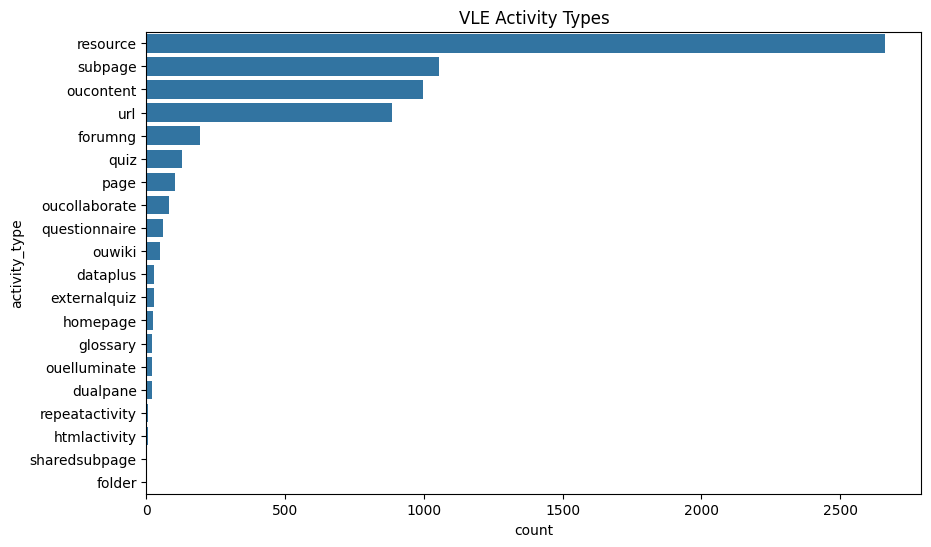

# Student VLE engagement summary
       code_module code_presentation    id_student       id_site  \
count     10655280          10655280  1.065528e+07  1.065528e+07   
unique           7                 4           NaN           NaN   
top            FFF             2014J           NaN           NaN   
freq       4014499           3619452           NaN           NaN   
mean           NaN               NaN  7.333336e+05  7.383234e+05   
std            NaN               NaN  5.827060e+05  1.312196e+05   
min            NaN               NaN  6.516000e+03  5.267210e+05   
25%            NaN               NaN  5.077430e+05  6.735190e+05   
50%            NaN               NaN  5.882360e+05  7.300690e+05   
75%            NaN               NaN  6.464840e+05  8.770300e+05   
max            NaN               NaN  2.698588e+06  1.049562e+06   

                date     sum_click  
count   1.065528e+07  1.065528e+07  
unique           NaN           NaN  
top              NaN           NaN  
fr

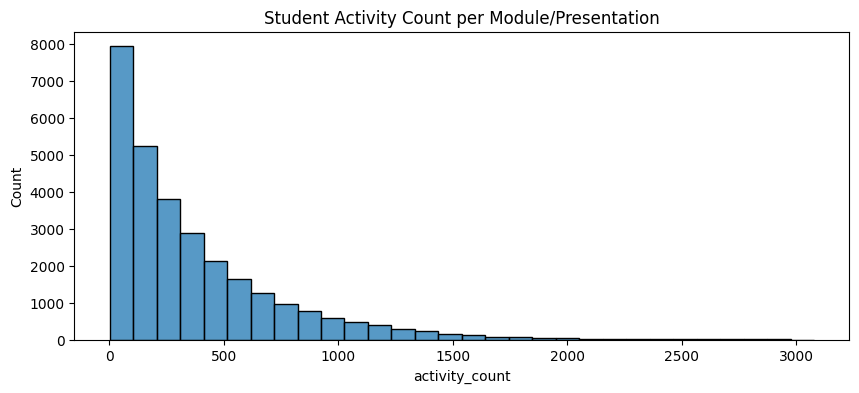

In [61]:
# VLE analysis
print("# VLE analysis")
print(df_vle.head())
print(df_vle['activity_type'].value_counts(dropna=False).head(20))
print('week_from missing:', df_vle['week_from'].isna().sum())
print('week_to missing:', df_vle['week_to'].isna().sum())

plt.figure(figsize=(10, 6))
sns.countplot(data=df_vle, y='activity_type', order=df_vle['activity_type'].value_counts().index)
plt.title('VLE Activity Types')
plt.show()

print("# Student VLE engagement summary")
print(df_studentVle.describe(include='all'))
engagement = df_studentVle.groupby(['id_student', 'code_module', 'code_presentation']).size().reset_index(name='activity_count')
print(engagement.describe(include='all'))

plt.figure(figsize=(10, 4))
sns.histplot(engagement['activity_count'], bins=30)
plt.title('Student Activity Count per Module/Presentation')
plt.xlabel('activity_count')
plt.show()


# Cross-dataset analysis
merged shape: (173912, 19)
imd_band                7697
date                    2865
score                    173
date_submitted             0
id_student                 0
id_assessment              0
code_module                0
code_presentation          0
assessment_type            0
weight                     0
is_banked                  0
gender                     0
region                     0
highest_education          0
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64
  final_result   count       mean  median        std
0  Distinction   26330  88.682947    91.0  11.435076
1         Fail   28399  64.685200    66.0  21.425457
2         Pass  105987  76.770745    79.0  16.458402
3    Withdrawn   13023  66.084927    70.0  23.181690


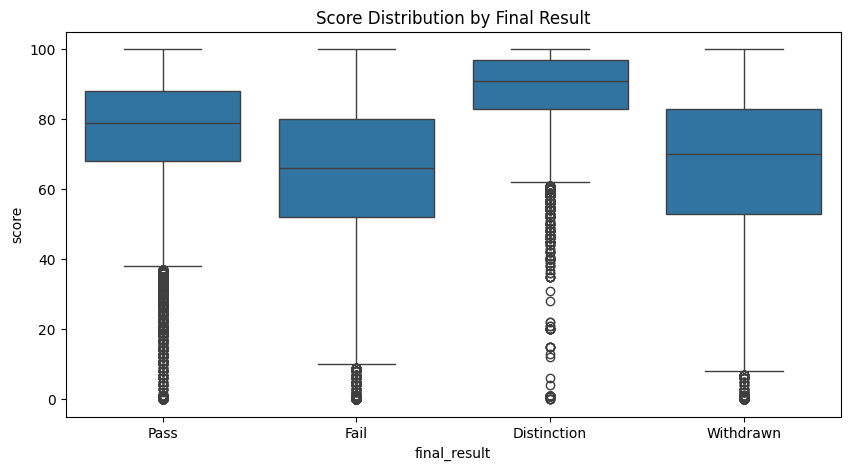

In [62]:
# Cross-dataset analysis
print("# Cross-dataset analysis")
merged = df_studentAssessments.merge(df_assessments, on='id_assessment', how='left')
merged = merged.merge(df_students, on=['code_module', 'code_presentation', 'id_student'], how='left')
print('merged shape:', merged.shape)
print(merged.isna().sum().sort_values(ascending=False).head(20))

result_score = merged.groupby('final_result')['score'].agg(['count', 'mean', 'median', 'std']).reset_index()
print(result_score)

plt.figure(figsize=(10, 5))
sns.boxplot(data=merged, x='final_result', y='score', order=merged['final_result'].value_counts().index)
plt.title('Score Distribution by Final Result')
plt.show()
